# Notebook 08 — Volatility Ratio Regression

**Purpose:** Predict the MAGNITUDE of tomorrow's EUR/USD move as a
continuous ratio in (0,1), instead of direction (UP/DOWN).

## Why this problem
- Direction ≈ white noise → hard (~54%).
- Magnitude (volatility) has clustering → more predictable.
- Supervisor guidance: model a **ratio in (0,1)**, not discrete classes.

## Problem type
- **Regression** (not classification): output is a continuous number.
- **Target:** |tomorrow's return|, min-max scaled to (0,1).
- **Metric:** MAE / RMSE (error), plus R² — NOT accuracy.

## Same as before (fair comparison)
- Same 31 features, same 70/20/10 chronological split.

---
**Author:** Đồng Công Gia Khang · **Date:** June 2026

## 1. Setup

In [1]:
"""
Setup: imports, paths, device.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_project_root(marker=".env"):
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / marker).exists():
            return p
    raise RuntimeError(f"Could not find {marker}")

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
MODELS_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project: {PROJECT_ROOT}")
print("Regressors ready: RandomForest, XGBoost, LightGBM")

Project: c:\Users\Khang\Desktop\Final Project 2
Regressors ready: RandomForest, XGBoost, LightGBM


## 2. Load Data & Build Volatility Ratio Target (0,1)

- Target = |tomorrow's return|, min-max scaled to (0,1).
- CRITICAL: min/max computed on TRAIN ONLY, then applied to val/test
  (computing them on all data would leak future volatility range).

In [2]:
"""
Load features + raw price, build volatility-ratio target in (0,1).
"""
# Features (already engineered)
feat = pd.read_csv(PROCESSED_DIR / "fx_features.csv", parse_dates=["date"])
feature_cols = [c for c in feat.columns
                if c not in ["date", "target_return_next_day", "target_direction"]]

# Raw EUR/USD price for computing tomorrow's move
master = pd.read_csv(INTERIM_DIR / "fx_master_dataset.csv",
                     parse_dates=["date"])[["date", "eurusd"]]
df = feat.merge(master, on="date", how="left").sort_values("date").reset_index(drop=True)

# Tomorrow's return, then its absolute magnitude
df["ret_next"] = df["eurusd"].pct_change().shift(-1)
df["abs_move"] = df["ret_next"].abs()

# Drop last row (no tomorrow) + any NaN
df = df.dropna(subset=["abs_move"]).reset_index(drop=True)

print(f"Rows: {len(df)}, features: {len(feature_cols)}")
print(f"abs_move range: {df['abs_move'].min():.5f} to {df['abs_move'].max():.5f}")
print(f"abs_move mean:  {df['abs_move'].mean():.5f}")

# Chronological split 70/20/10
n = len(df)
i70, i90 = int(n*0.70), int(n*0.90)
train_df = df.iloc[:i70].reset_index(drop=True)
val_df   = df.iloc[i70:i90].reset_index(drop=True)
test_df  = df.iloc[i90:].reset_index(drop=True)

# Min-max scale to (0,1) using TRAIN ONLY
vmin = train_df["abs_move"].min()
vmax = train_df["abs_move"].max()

def to_ratio(s):
    return ((s - vmin) / (vmax - vmin)).clip(0, 1)   # clip: test extremes stay in [0,1]

y_train = to_ratio(train_df["abs_move"]).values
y_val   = to_ratio(val_df["abs_move"]).values
y_test  = to_ratio(test_df["abs_move"]).values

print(f"\nSplit: Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
print(f"Ratio target (train): min {y_train.min():.3f}, max {y_train.max():.3f}, mean {y_train.mean():.3f}")
print(f"Scaling min/max (from TRAIN): {vmin:.5f} / {vmax:.5f}")

Rows: 4083, features: 31
abs_move range: 0.00000 to 0.03176
abs_move mean:  0.00403

Split: Train 2858 | Val 816 | Test 409
Ratio target (train): min 0.000, max 1.000, mean 0.132
Scaling min/max (from TRAIN): 0.00000 / 0.03176


## 3. Baseline & Evaluation Helper

Regression baseline = always predict the TRAIN mean ratio.
A useful model must beat it. Metrics:
- **MAE** (mean absolute error) — lower is better
- **RMSE** — lower is better, punishes big misses
- **R²** — fraction of variance explained; R² > 0 means better than baseline

In [3]:
"""
Baseline (predict train mean) + evaluation helper.
"""
X_train = train_df[feature_cols].values
X_val   = val_df[feature_cols].values
X_test  = test_df[feature_cols].values

# Baseline: predict the mean of train target for everything
baseline_pred_val  = np.full_like(y_val,  y_train.mean())
baseline_pred_test = np.full_like(y_test, y_train.mean())

base_val_mae  = mean_absolute_error(y_val,  baseline_pred_val)
base_test_mae = mean_absolute_error(y_test, baseline_pred_test)

print("BASELINE (predict train mean)")
print(f"  Val  MAE: {base_val_mae:.4f}")
print(f"  Test MAE: {base_test_mae:.4f}")
print("  (R2 = 0 by definition for the mean predictor)\n")

results = {}

def evaluate_reg(name, model):
    pv = model.predict(X_val)
    pt = model.predict(X_test)
    # clip predictions to (0,1) since target is a ratio
    pv = np.clip(pv, 0, 1); pt = np.clip(pt, 0, 1)
    mae_v = mean_absolute_error(y_val, pv)
    rmse_v = np.sqrt(mean_squared_error(y_val, pv))
    r2_v = r2_score(y_val, pv)
    mae_t = mean_absolute_error(y_test, pt)
    r2_t = r2_score(y_test, pt)
    results[name] = {"val_mae": mae_v, "val_rmse": rmse_v, "val_r2": r2_v,
                     "test_mae": mae_t, "test_r2": r2_t}
    print(f"=== {name} ===")
    print(f"  Val  MAE {mae_v:.4f}  (baseline {base_val_mae:.4f})  |  R2 {r2_v:+.4f}")
    print(f"  Test MAE {mae_t:.4f}  (baseline {base_test_mae:.4f})  |  R2 {r2_t:+.4f}")
    improve = (base_val_mae - mae_v) / base_val_mae * 100
    print(f"  Val MAE improvement over baseline: {improve:+.1f}%")

print("Helper ready.")

BASELINE (predict train mean)
  Val  MAE: 0.0823
  Test MAE: 0.0803
  (R2 = 0 by definition for the mean predictor)

Helper ready.


## 4. Train ML Regressors (RF, XGBoost, LightGBM)

Same 3 model families as before, but Regressor versions.
Same hyperparameters style (shallow, regularized) to control overfitting.

In [4]:
"""
Train 3 ML regressors on the volatility-ratio target.
"""
rf = RandomForestRegressor(
    n_estimators=300, max_depth=6, min_samples_leaf=20,
    random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate_reg("Random Forest", rf)

xgb = XGBRegressor(
    n_estimators=400, max_depth=3, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=20,
    reg_lambda=2.0, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
evaluate_reg("XGBoost", xgb)

lgbm = LGBMRegressor(
    n_estimators=400, max_depth=3, num_leaves=7, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    reg_lambda=2.0, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
evaluate_reg("LightGBM", lgbm)

=== Random Forest ===
  Val  MAE 0.0741  (baseline 0.0823)  |  R2 +0.0775
  Test MAE 0.0736  (baseline 0.0803)  |  R2 +0.0010
  Val MAE improvement over baseline: +9.9%
=== XGBoost ===
  Val  MAE 0.0734  (baseline 0.0823)  |  R2 +0.0744
  Test MAE 0.0727  (baseline 0.0803)  |  R2 -0.0029
  Val MAE improvement over baseline: +10.8%
=== LightGBM ===
  Val  MAE 0.0744  (baseline 0.0823)  |  R2 +0.0541
  Test MAE 0.0731  (baseline 0.0803)  |  R2 +0.0059
  Val MAE improvement over baseline: +9.5%


## 5. Visualize Predictions & Save

Best by val MAE: XGBoost


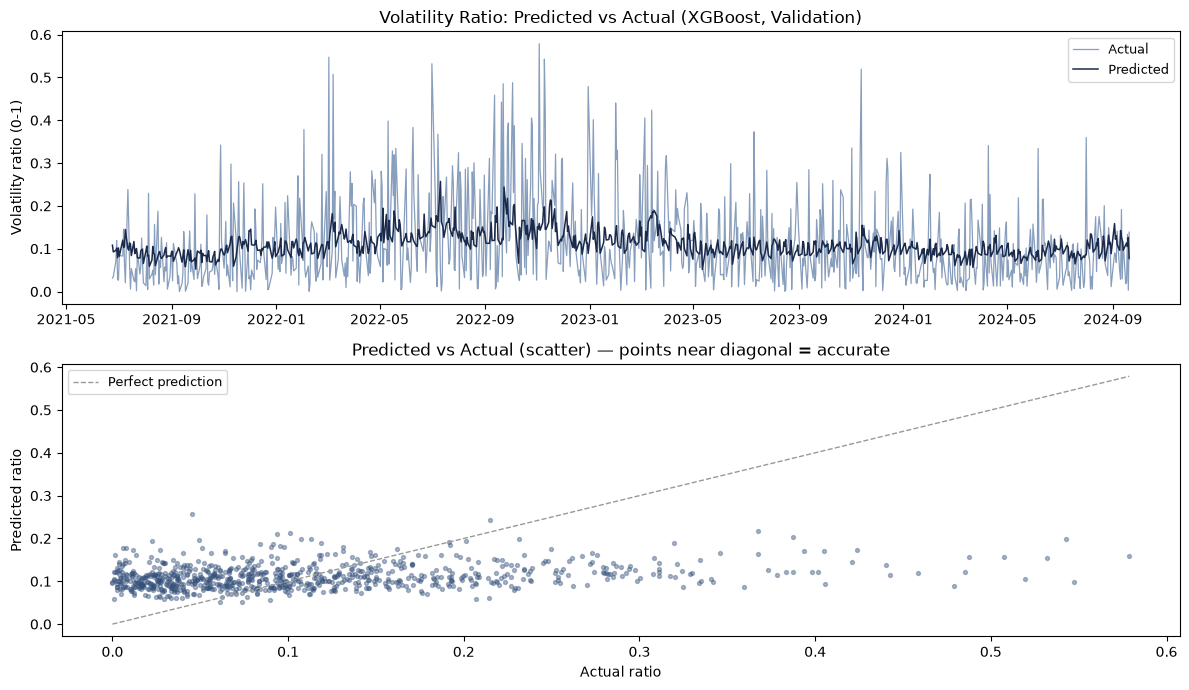


VOLATILITY REGRESSION — all models
               val_mae  val_rmse  val_r2  test_mae  test_r2
Random Forest   0.0741    0.0970  0.0775    0.0736   0.0010
XGBoost         0.0734    0.0972  0.0744    0.0727  -0.0029
LightGBM        0.0744    0.0983  0.0541    0.0731   0.0059

Saved 3 models + volatility_results.csv


In [5]:
"""
Plot predicted vs actual volatility ratio (best model = XGBoost), and save.
"""
import joblib

# Best by validation MAE
best_name = min(results, key=lambda k: results[k]["val_mae"])
best_model = {"Random Forest": rf, "XGBoost": xgb, "LightGBM": lgbm}[best_name]
print(f"Best by val MAE: {best_name}")

pred_val = np.clip(best_model.predict(X_val), 0, 1)

# Plot 1: predicted vs actual over time (validation)
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

ax = axes[0]
ax.plot(val_df["date"], y_val, label="Actual", color="#6b86ad", linewidth=0.9, alpha=0.8)
ax.plot(val_df["date"], pred_val, label="Predicted", color="#1b2a4a", linewidth=1.1)
ax.set_title(f"Volatility Ratio: Predicted vs Actual ({best_name}, Validation)")
ax.set_ylabel("Volatility ratio (0-1)")
ax.legend(fontsize=9)

# Plot 2: scatter predicted vs actual
ax = axes[1]
ax.scatter(y_val, pred_val, s=8, alpha=0.4, color="#34507a")
lims = [0, max(y_val.max(), pred_val.max())]
ax.plot(lims, lims, "--", color="#999999", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual ratio"); ax.set_ylabel("Predicted ratio")
ax.set_title("Predicted vs Actual (scatter) — points near diagonal = accurate")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "08_volatility_regression.png", dpi=120)
plt.show()

# Results table + save
reg_results = pd.DataFrame(results).T.round(4)
print("\n" + "="*60)
print("VOLATILITY REGRESSION — all models")
print("="*60)
print(reg_results.to_string())

joblib.dump(rf,   MODELS_DIR / "vol_random_forest.pkl")
joblib.dump(xgb,  MODELS_DIR / "vol_xgboost.pkl")
joblib.dump(lgbm, MODELS_DIR / "vol_lightgbm.pkl")
reg_results.to_csv(MODELS_DIR / "volatility_results.csv")
print("\nSaved 3 models + volatility_results.csv")

## 6. EDA — How Features Relate to Volatility (vs Direction)

Supervisor question: how do the features relate to the target, and which
ones does the model actually use? We compare feature–target relationships
for the NEW volatility target against the OLD direction target.

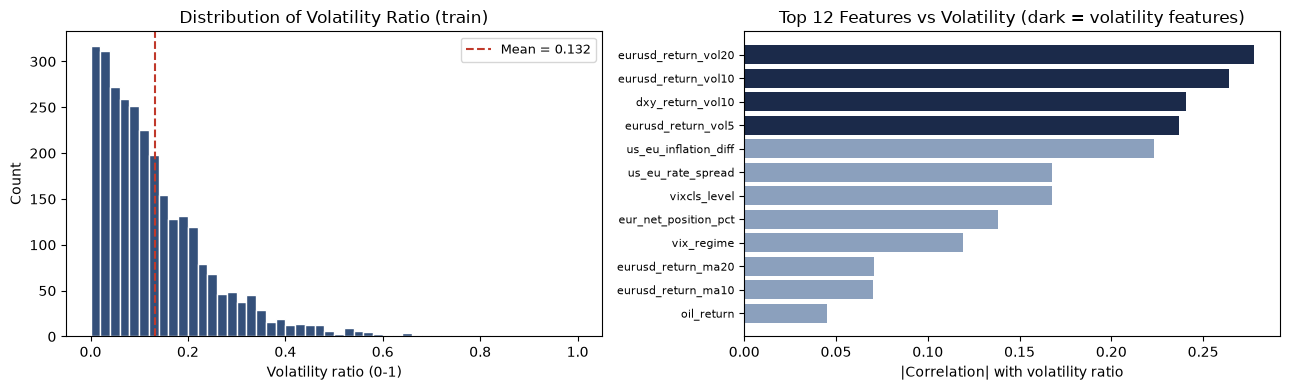

Top features correlated with VOLATILITY ratio:
eurusd_return_vol20     0.278
eurusd_return_vol10     0.264
dxy_return_vol10        0.241
eurusd_return_vol5      0.237
us_eu_inflation_diff    0.223
us_eu_rate_spread       0.168
vixcls_level            0.168
eur_net_position_pct    0.138


In [6]:
"""
EDA part 1: target distribution + feature correlations with volatility ratio.
"""
# Rebuild direction target for comparison
df["dir_target"] = (df["ret_next"] > 0).astype(int)
y_dir_train = df["dir_target"].iloc[:i70].values

# --- Plot 1: distribution of volatility ratio target ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(y_train, bins=50, color="#34507a", edgecolor="white")
ax.axvline(y_train.mean(), color="#c0392b", linestyle="--", linewidth=1.5,
           label=f"Mean = {y_train.mean():.3f}")
ax.set_title("Distribution of Volatility Ratio (train)")
ax.set_xlabel("Volatility ratio (0-1)"); ax.set_ylabel("Count")
ax.legend(fontsize=9)

# --- Plot 2: top features correlated with volatility ratio ---
train_feat = train_df[feature_cols].copy()
vol_corr = train_feat.apply(lambda c: np.corrcoef(c, y_train)[0, 1])
vol_corr_abs = vol_corr.abs().sort_values(ascending=False).head(12)

ax = axes[1]
colors = ["#1b2a4a" if "vol" in f else "#8ba0bd" for f in vol_corr_abs.index]
ax.barh(range(len(vol_corr_abs)), vol_corr_abs.values, color=colors)
ax.set_yticks(range(len(vol_corr_abs)))
ax.set_yticklabels(vol_corr_abs.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("|Correlation| with volatility ratio")
ax.set_title("Top 12 Features vs Volatility (dark = volatility features)")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_eda_volatility_features.png", dpi=120)
plt.show()

print("Top features correlated with VOLATILITY ratio:")
print(vol_corr_abs.head(8).round(3).to_string())

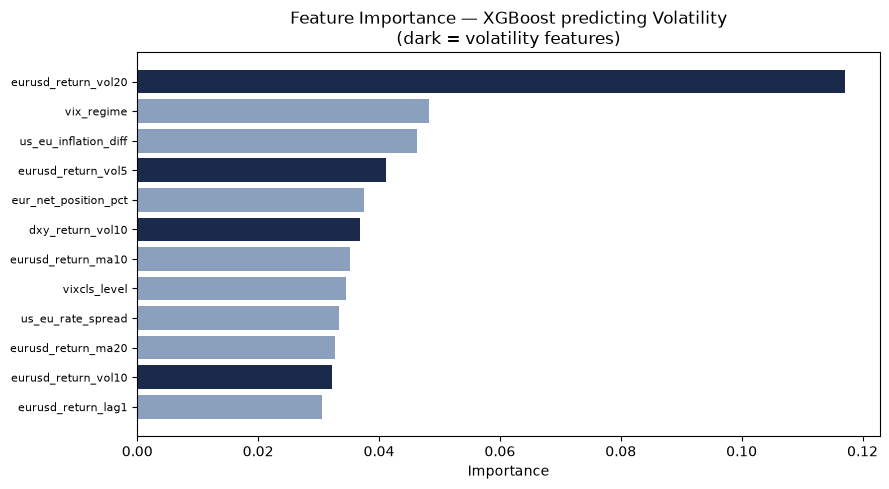

Top features USED by model to predict volatility:
eurusd_return_vol20     0.1170
vix_regime              0.0482
us_eu_inflation_diff    0.0463
eurusd_return_vol5      0.0411
eur_net_position_pct    0.0375
dxy_return_vol10        0.0368
eurusd_return_ma10      0.0352
vixcls_level            0.0345

KEY COMPARISON — same features, two targets
                      corr_with_direction  corr_with_volatility
eurusd_return_vol20                 0.002                 0.278
eurusd_return_vol10                 0.009                 0.264
dxy_return_vol10                    0.005                 0.241
eurusd_return_vol5                  0.001                 0.237
us_eu_inflation_diff                0.005                 0.223
us_eu_rate_spread                   0.011                 0.168
vixcls_level                        0.010                 0.168
eur_net_position_pct                0.025                 0.138

-> Features relate MUCH more strongly to volatility than to direction.


In [7]:
"""
EDA part 2: feature importance from the trained model
(what the model actually USES to predict volatility).
"""
# Feature importance from best model (XGBoost)
importances = best_model.feature_importances_
imp_series = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#1b2a4a" if "vol" in f else "#8ba0bd" for f in imp_series.index]
ax.barh(range(len(imp_series)), imp_series.values, color=colors)
ax.set_yticks(range(len(imp_series)))
ax.set_yticklabels(imp_series.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title(f"Feature Importance — {best_name} predicting Volatility\n(dark = volatility features)")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_vol_feature_importance.png", dpi=120)
plt.show()

print("Top features USED by model to predict volatility:")
print(imp_series.head(8).round(4).to_string())

# Direct comparison: correlation with direction vs volatility
print("\n" + "="*60)
print("KEY COMPARISON — same features, two targets")
print("="*60)
dir_corr = train_feat.apply(lambda c: abs(np.corrcoef(c, y_dir_train)[0, 1]))
compare = pd.DataFrame({
    "corr_with_direction": dir_corr,
    "corr_with_volatility": vol_corr.abs(),
}).sort_values("corr_with_volatility", ascending=False).head(8)
print(compare.round(3).to_string())
print("\n-> Features relate MUCH more strongly to volatility than to direction.")

## 7. Version 2 — Classification (High/Low Volatility)

Supervisor wants an accuracy %. Regression has none, so we reframe:
- Split volatility ratio at the TRAIN median → 1 = high vol, 0 = low vol.
- Median split → baseline ~50%, so accuracy above 50% is a real edge.
- CRITICAL: threshold from TRAIN only (applying to val/test = no leak).

In [8]:
"""
Build binary high/low-volatility target (median split on train).
"""
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

# Threshold = median of TRAIN volatility ratio
vol_median = np.median(y_train)
print(f"Train median volatility ratio: {vol_median:.4f}")

# Binary labels: 1 if above median (high vol), else 0
yc_train = (y_train > vol_median).astype(int)
yc_val   = (y_val   > vol_median).astype(int)
yc_test  = (y_test  > vol_median).astype(int)

print(f"\nClass balance (high-vol %):")
print(f"  Train: {yc_train.mean()*100:.1f}%")
print(f"  Val:   {yc_val.mean()*100:.1f}%")
print(f"  Test:  {yc_test.mean()*100:.1f}%")

# Baselines (majority class)
VAL_BASE_C  = max(yc_val.mean(),  1 - yc_val.mean())
TEST_BASE_C = max(yc_test.mean(), 1 - yc_test.mean())
print(f"\nVal baseline:  {VAL_BASE_C*100:.2f}%")
print(f"Test baseline: {TEST_BASE_C*100:.2f}%")

Train median volatility ratio: 0.1014

Class balance (high-vol %):
  Train: 50.0%
  Val:   43.0%
  Test:  43.0%

Val baseline:  56.99%
Test baseline: 56.97%


In [9]:
"""
Train 3 classifiers on high/low volatility.
"""
results_c = {}

def eval_clf(name, model):
    tr = accuracy_score(yc_train, model.predict(X_train))
    va = accuracy_score(yc_val,   model.predict(X_val))
    te = accuracy_score(yc_test,  model.predict(X_test))
    results_c[name] = {"train": tr, "val": va, "test": te}
    print(f"=== {name} ===")
    print(f"  Train: {tr*100:5.2f}%")
    print(f"  Val:   {va*100:5.2f}%   vs baseline {VAL_BASE_C*100:.2f}%  ({(va-VAL_BASE_C)*100:+.2f} pp)")
    print(f"  Test:  {te*100:5.2f}%   vs baseline {TEST_BASE_C*100:.2f}%  ({(te-TEST_BASE_C)*100:+.2f} pp)")

rfc = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                             random_state=42, n_jobs=-1)
rfc.fit(X_train, yc_train); eval_clf("Random Forest", rfc)

xgbc = XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.03,
                     subsample=0.8, colsample_bytree=0.8, min_child_weight=20,
                     reg_lambda=2.0, eval_metric="logloss", random_state=42, n_jobs=-1)
xgbc.fit(X_train, yc_train); eval_clf("XGBoost", xgbc)

lgbmc = LGBMClassifier(n_estimators=400, max_depth=3, num_leaves=7, learning_rate=0.03,
                       subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
                       reg_lambda=2.0, random_state=42, n_jobs=-1, verbose=-1)
lgbmc.fit(X_train, yc_train); eval_clf("LightGBM", lgbmc)

=== Random Forest ===
  Train: 68.26%
  Val:   59.68%   vs baseline 56.99%  (+2.70 pp)
  Test:  57.46%   vs baseline 56.97%  (+0.49 pp)
=== XGBoost ===
  Train: 74.60%
  Val:   59.56%   vs baseline 56.99%  (+2.57 pp)
  Test:  56.72%   vs baseline 56.97%  (-0.24 pp)
=== LightGBM ===
  Train: 74.32%
  Val:   59.80%   vs baseline 56.99%  (+2.82 pp)
  Test:  55.26%   vs baseline 56.97%  (-1.71 pp)


## 8. Deep Learning for Both Versions (LSTM & GRU)

Add RNN models to match NB05-07. Same windowing (10 days) + scaling.
- Regression version: RNN outputs a continuous ratio (loss = MSE).
- Classification version: RNN outputs high/low label (loss = BCE).

In [10]:
"""
Shared: scale (train-fit) + build 10-day windows for both targets.
"""
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WINDOW = 10

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xva_s = scaler.transform(X_val)
Xte_s = scaler.transform(X_test)

def make_windows(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i]); ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# Regression targets (ratio)
Xtr_w, ytr_reg = make_windows(Xtr_s, y_train, WINDOW)
Xva_w, yva_reg = make_windows(Xva_s, y_val,   WINDOW)
Xte_w, yte_reg = make_windows(Xte_s, y_test,  WINDOW)

# Classification targets (high/low) — same windows, different y
_, ytr_clf = make_windows(Xtr_s, yc_train.astype(float), WINDOW)
_, yva_clf = make_windows(Xva_s, yc_val.astype(float),   WINDOW)
_, yte_clf = make_windows(Xte_s, yc_test.astype(float),  WINDOW)

print(f"Windows: Train {Xtr_w.shape}, Val {Xva_w.shape}, Test {Xte_w.shape}")

n_features = Xtr_w.shape[2]
Xva_t = torch.tensor(Xva_w).to(device)
Xte_t = torch.tensor(Xte_w).to(device)
Xtr_t = torch.tensor(Xtr_w).to(device)

class RNN(nn.Module):
    def __init__(self, n_features, hidden=32, dropout=0.3, rnn_type="LSTM", task="reg"):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        self.rnn = rnn_cls(n_features, hidden, batch_first=True)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden, 16), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(16, 1))
        self.task = task
    def forward(self, x):
        out, _ = self.rnn(x)
        z = self.head(out[:, -1, :]).squeeze(-1)
        return torch.sigmoid(z) if self.task == "reg" else z  # reg: (0,1); clf: logit

print("RNN class ready.")

Windows: Train (2848, 10, 31), Val (806, 10, 31), Test (399, 10, 31)
RNN class ready.


In [11]:
"""
Train LSTM & GRU REGRESSORS (volatility ratio).
"""
def train_rnn_reg(rnn_type, epochs=80, lr=1e-3, wd=1e-4, patience=12):
    torch.manual_seed(SEED)
    model = RNN(n_features, rnn_type=rnn_type, task="reg").to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.MSELoss()
    loader = DataLoader(TensorDataset(torch.tensor(Xtr_w), torch.tensor(ytr_reg)),
                        batch_size=64, shuffle=True)
    best, best_state, wait = 1e9, None, 0
    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            pv = model(Xva_t).cpu().numpy()
        vmae = mean_absolute_error(yva_reg, np.clip(pv, 0, 1))
        if vmae < best:
            best, best_state, wait = vmae, {k: v.cpu().clone() for k,v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state)
    with torch.no_grad():
        pv = np.clip(model(Xva_t).cpu().numpy(), 0, 1)
        pt = np.clip(model(Xte_t).cpu().numpy(), 0, 1)
    mae_v = mean_absolute_error(yva_reg, pv); r2_v = r2_score(yva_reg, pv)
    mae_t = mean_absolute_error(yte_reg, pt); r2_t = r2_score(yte_reg, pt)
    results[rnn_type] = {"val_mae": mae_v, "val_rmse": np.sqrt(mean_squared_error(yva_reg,pv)),
                         "val_r2": r2_v, "test_mae": mae_t, "test_r2": r2_t}
    print(f"=== {rnn_type} (regression) ===")
    print(f"  Val  MAE {mae_v:.4f}  R2 {r2_v:+.4f}")
    print(f"  Test MAE {mae_t:.4f}  R2 {r2_t:+.4f}")
    return model

# baseline MAE on windowed val for reference
base_w = mean_absolute_error(yva_reg, np.full_like(yva_reg, ytr_reg.mean()))
print(f"Windowed val baseline MAE: {base_w:.4f}\n")
lstm_reg = train_rnn_reg("LSTM")
gru_reg  = train_rnn_reg("GRU")

Windowed val baseline MAE: 0.0824

=== LSTM (regression) ===
  Val  MAE 0.0714  R2 +0.0215
  Test MAE 0.0698  R2 -0.0443
=== GRU (regression) ===
  Val  MAE 0.0728  R2 -0.0394
  Test MAE 0.0697  R2 -0.0238


In [12]:
"""
Train LSTM & GRU CLASSIFIERS (high/low volatility).
"""
def train_rnn_clf(rnn_type, epochs=80, lr=1e-3, wd=1e-4, patience=12):
    torch.manual_seed(SEED)
    model = RNN(n_features, rnn_type=rnn_type, task="clf").to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(TensorDataset(torch.tensor(Xtr_w), torch.tensor(ytr_clf)),
                        batch_size=64, shuffle=True)
    best, best_state, wait = 0.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            pv = (torch.sigmoid(model(Xva_t)) >= 0.5).long().cpu().numpy()
        vacc = accuracy_score(yva_clf, pv)
        if vacc > best:
            best = vacc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    with torch.no_grad():
        pv = (torch.sigmoid(model(Xva_t)) >= 0.5).long().cpu().numpy()
        pt = (torch.sigmoid(model(Xte_t)) >= 0.5).long().cpu().numpy()
        ptr = (torch.sigmoid(model(Xtr_t)) >= 0.5).long().cpu().numpy()
    tr = accuracy_score(ytr_clf, ptr)
    va = accuracy_score(yva_clf, pv)
    te = accuracy_score(yte_clf, pt)
    results_c[rnn_type] = {"train": tr, "val": va, "test": te}
    edge_v = (va - VAL_BASE_C) * 100
    edge_t = (te - TEST_BASE_C) * 100
    print("===", rnn_type, "(classification) ===")
    print("  Train:", round(tr * 100, 2), "%")
    print("  Val:  ", round(va * 100, 2), "%  vs baseline", round(VAL_BASE_C * 100, 2), "  (", round(edge_v, 2), "pp )")
    print("  Test: ", round(te * 100, 2), "%  vs baseline", round(TEST_BASE_C * 100, 2), "  (", round(edge_t, 2), "pp )")
    return model

lstm_clf = train_rnn_clf("LSTM")
gru_clf = train_rnn_clf("GRU")

=== LSTM (classification) ===
  Train: 63.06 %
  Val:   59.93 %  vs baseline 56.99   ( 2.94 pp )
  Test:  57.89 %  vs baseline 56.97   ( 0.93 pp )
=== GRU (classification) ===
  Train: 61.41 %
  Val:   59.8 %  vs baseline 56.99   ( 2.82 pp )
  Test:  57.89 %  vs baseline 56.97   ( 0.93 pp )


In [13]:
"""
Final summary: both versions, all 5 models + save.
"""
import joblib

print("="*64)
print("VERSION 1 — REGRESSION (volatility ratio)  |  lower MAE better, R2>0 good")
print("="*64)
reg_all = pd.DataFrame(results).T
reg_all = reg_all[["val_mae","val_r2","test_mae","test_r2"]].round(4)
print(reg_all.to_string())
print(f"\nBaseline val MAE ~0.082 | Best by val MAE: {reg_all['val_mae'].idxmin()}")

print("\n" + "="*64)
print("VERSION 2 — CLASSIFICATION (high/low vol)  |  accuracy %, baseline ~57%")
print("="*64)
clf_all = pd.DataFrame(results_c).T
clf_all = (clf_all[["train","val","test"]]*100).round(2)
clf_all["val_vs_base"] = (clf_all["val"] - VAL_BASE_C*100).round(2)
print(clf_all.to_string())
print(f"\nVal baseline {VAL_BASE_C*100:.2f}% | Best by val: {clf_all['val'].idxmax()}")

# Save everything
torch.save(lstm_reg.state_dict(), MODELS_DIR / "vol_reg_lstm.pt")
torch.save(gru_reg.state_dict(),  MODELS_DIR / "vol_reg_gru.pt")
torch.save(lstm_clf.state_dict(), MODELS_DIR / "vol_clf_lstm.pt")
torch.save(gru_clf.state_dict(),  MODELS_DIR / "vol_clf_gru.pt")
joblib.dump(rfc,   MODELS_DIR / "vol_clf_random_forest.pkl")
joblib.dump(xgbc,  MODELS_DIR / "vol_clf_xgboost.pkl")
joblib.dump(lgbmc, MODELS_DIR / "vol_clf_lightgbm.pkl")
reg_all.to_csv(MODELS_DIR / "volatility_regression_results.csv")
clf_all.to_csv(MODELS_DIR / "volatility_classification_results.csv")
print("\nSaved all volatility models + 2 result CSVs")

VERSION 1 — REGRESSION (volatility ratio)  |  lower MAE better, R2>0 good
               val_mae  val_r2  test_mae  test_r2
Random Forest   0.0741  0.0775    0.0736   0.0010
XGBoost         0.0734  0.0744    0.0727  -0.0029
LightGBM        0.0744  0.0541    0.0731   0.0059
LSTM            0.0714  0.0215    0.0698  -0.0443
GRU             0.0728 -0.0394    0.0697  -0.0238

Baseline val MAE ~0.082 | Best by val MAE: LSTM

VERSION 2 — CLASSIFICATION (high/low vol)  |  accuracy %, baseline ~57%
               train    val   test  val_vs_base
Random Forest  68.26  59.68  57.46         2.69
XGBoost        74.60  59.56  56.72         2.57
LightGBM       74.32  59.80  55.26         2.81
LSTM           63.06  59.93  57.89         2.94
GRU            61.41  59.80  57.89         2.81

Val baseline 56.99% | Best by val: LSTM

Saved all volatility models + 2 result CSVs


In [14]:
"""
Standalone: refit and save the volatility scaler + scaling constants.
"""
from pathlib import Path
import pandas as pd
import numpy as np
import joblib, json
from sklearn.preprocessing import StandardScaler

def _root(marker=".env"):
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / marker).exists():
            return p
    return Path.cwd()

ROOT = _root()
MODELS_DIR = ROOT / "models"

feat = pd.read_csv(ROOT / "data" / "processed" / "fx_features.csv", parse_dates=["date"])
feature_cols = [c for c in feat.columns
                if c not in ["date", "target_return_next_day", "target_direction"]]
master = pd.read_csv(ROOT / "data" / "interim" / "fx_master_dataset.csv",
                     parse_dates=["date"])[["date", "eurusd"]]

df = feat.merge(master, on="date", how="left").sort_values("date").reset_index(drop=True)
df["ret_next"] = df["eurusd"].pct_change().shift(-1)
df["abs_move"] = df["ret_next"].abs()
df = df.dropna(subset=["abs_move"]).reset_index(drop=True)

n = len(df)
i70 = int(n * 0.70)
train_df = df.iloc[:i70]

vmin = float(train_df["abs_move"].min())
vmax = float(train_df["abs_move"].max())
y_train_ratio = ((train_df["abs_move"] - vmin) / (vmax - vmin)).clip(0, 1).values
vol_median = float(np.median(y_train_ratio))

scaler = StandardScaler().fit(train_df[feature_cols])   # TRAIN ONLY
joblib.dump(scaler, MODELS_DIR / "scaler_volatility.pkl")

meta = {"vmin": vmin, "vmax": vmax, "vol_median": vol_median,
        "feature_cols": feature_cols, "window": 10}
with open(MODELS_DIR / "vol_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved scaler_volatility.pkl + vol_meta.json")
print(f"vmin={vmin:.6f}  vmax={vmax:.6f}  median={vol_median:.4f}")
print(f"Scaler fitted on {scaler.n_features_in_} features")

Saved scaler_volatility.pkl + vol_meta.json
vmin=0.000000  vmax=0.031756  median=0.1014
Scaler fitted on 31 features
